# **Part- A: Data Preparation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
fear_greed_data = pd.read_csv("/content/fear_greed_index.csv")
historical_data = pd.read_csv("/content/historical_data.csv")

In [3]:
fear_greed_data

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [4]:
historical_data

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


# Step 1
In the first step of data preparation, I'll perform an initial data inspection on both `fear_greed_data` and `historical_data` to understand their structure and quality. This involves displaying the number of rows and columns, checking for any missing values, and identifying duplicate entries in each DataFrame.

In [5]:
print("===== fear_greed_data Inspection =====\n")

print("Shape:", fear_greed_data.shape)

print("\nMissing Values:\n", fear_greed_data.isnull().sum())

print("\nDuplicate Rows:", fear_greed_data.duplicated().sum())

print("\n===== historical_data Inspection =====")
print("Shape:", historical_data.shape)
print("\nMissing Values:\n", historical_data.isnull().sum())
print("\nDuplicate Rows:", historical_data.duplicated().sum())

===== fear_greed_data Inspection =====

Shape: (2644, 4)

Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0

===== historical_data Inspection =====
Shape: (211224, 16)

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows: 0


## Convert Timestamps and Align Data

Convert the 'date' column in 'fear_greed_data' and the 'Timestamp IST' column in 'historical_data' to datetime

**Reasoning**:
First, I need to convert the 'date' column in `frear_greed_data` to a datetime object and extract only the date part. This ensures proper type for date-based operations and alignment.



In [6]:
fear_greed_data.dtypes

,0
timestamp,int64
value,int64
classification,object
date,object


In [7]:
# Note: Date is already in the object type

In [8]:
historical_data['Timestamp IST'] = pd.to_datetime(historical_data['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

print("historical_data 'Timestamp IST' column converted to date objects.")

historical_data.head()

historical_data 'Timestamp IST' column converted to date objects.


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
historical_data.dtypes

,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,object
Start Position,float64
Direction,object
Closed PnL,float64


**Now the time stamp is conveted into the object**

In [10]:
daily_historical_data = historical_data.groupby('Timestamp IST').agg(
    daily_closed_pnl=('Closed PnL', 'sum'),
    daily_size_usd=('Size USD', 'sum'),
    daily_trade_count=('Trade ID', 'count')
).reset_index()

print("Historical data aggregated to daily level.")
daily_historical_data.head()

Historical data aggregated to daily level.


,Timestamp IST,daily_closed_pnl,daily_size_usd,daily_trade_count
0,2023-05-01,0.000000,477.00,3
1,2023-12-05,0.000000,50005.83,9
2,2023-12-14,-205.434737,113203.35,11
3,2023-12-15,-24.632034,10609.95,2
4,2023-12-16,0.000000,15348.77,3


In [11]:
combined_data = pd.merge(fear_greed_data, daily_historical_data, left_on='date', right_on='Timestamp IST', how='inner')

print("Datasets merged successfully.")
combined_data.head()

Datasets merged successfully.


,timestamp,value,classification,date,Timestamp IST,daily_closed_pnl,daily_size_usd,daily_trade_count


## Calculate Daily PnL per Trader

Calculate the daily Profit and Loss (PnL) for each unique (trader) from the 'historical_data'.


In [12]:
daily_pnl_per_trader = historical_data.groupby(['Account', 'Timestamp IST'])['Closed PnL'].sum().reset_index()

daily_pnl_per_trader.rename(columns={'Closed PnL': 'Daily PnL'}, inplace=True)

print("Daily PnL per trader calculated successfully.")

daily_pnl_per_trader.head()

Daily PnL per trader calculated successfully.


,Account,Timestamp IST,Daily PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


## Calculate Win Rate per Trader

Determine the win rate for each trader. This involves counting the number of profitable trades (where 'Closed PnL' > 0) and dividing by the total number of trades for each 'Account'.


In [13]:
profitable_trades = historical_data[historical_data['Closed PnL'] > 0]

total_trades_per_trader = historical_data.groupby('Account').size().rename('Total Trades')

profitable_trades_per_trader = profitable_trades.groupby('Account').size().rename('Profitable Trades')

print("Profitable trades filtered, and total/profitable trades per trader counted.")

print("\nTotal Trades per Trader head:\n", total_trades_per_trader.head())

print("\nProfitable Trades per Trader head:\n", profitable_trades_per_trader.head())

Profitable trades filtered, and total/profitable trades per trader counted.

Total Trades per Trader head:
 Account
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0x271b280974205ca63b716753467d5a371de622ab     3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
Name: Total Trades, dtype: int64

Profitable Trades per Trader head:
 Account
0x083384f897ee0f19899168e3b1bec365f52a9012    1373
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    3223
0x271b280974205ca63b716753467d5a371de622ab    1150
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    5838
0x2c229d22b100a7beb69122eed721cee9b24011dd    1684
Name: Profitable Trades, dtype: int64


In [14]:
win_rate_per_trader = pd.DataFrame({'Total Trades': total_trades_per_trader, 'Profitable Trades': profitable_trades_per_trader})

win_rate_per_trader['Profitable Trades'] = win_rate_per_trader['Profitable Trades'].fillna(0)

win_rate_per_trader['Win Rate'] = (win_rate_per_trader['Profitable Trades'] / win_rate_per_trader['Total Trades']) * 100

win_rate_per_trader = win_rate_per_trader.reset_index().rename(columns={'index': 'Account'})

print("Win rate per trader calculated successfully.")

print(win_rate_per_trader[['Account', 'Win Rate']].head())

Win rate per trader calculated successfully.
                                      Account   Win Rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  35.961236
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  44.271978
2  0x271b280974205ca63b716753467d5a371de622ab  30.191651
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  43.858463
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  51.991355


## Calculate Average Trade Size per Trader

Compute the average trade size for each trader. This can be calculated by averaging the 'Size USD' or 'Size Tokens' for each 'Account'.


In [15]:
average_trade_size_per_trader = historical_data.groupby('Account')['Size USD'].mean().reset_index()

average_trade_size_per_trader.rename(columns={'Size USD': 'Average Trade Size (USD)'}, inplace=True)

print("Average trade size per trader calculated successfully.")
average_trade_size_per_trader.head()

Average trade size per trader calculated successfully.


,Account,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


## Analyze Trade Size Distribution (Leverage Proxy)

Analyze the distribution of trade sizes (using 'Size USD' or 'Size Tokens') as a proxy for 'leverage distribution'


In [16]:
print("Descriptive statistics for 'Size USD':")
print(historical_data['Size USD'].describe())

Descriptive statistics for 'Size USD':
count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64


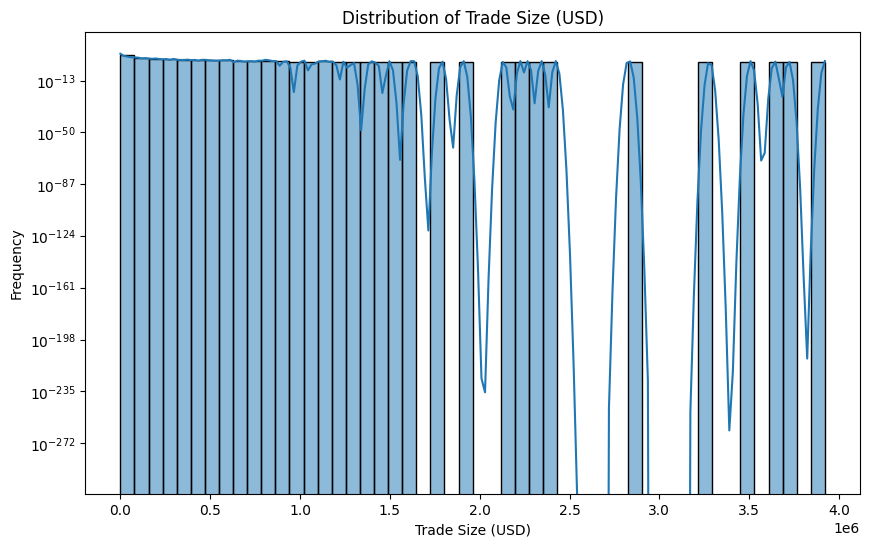

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(historical_data['Size USD'], bins=50, kde=True)
plt.title('Distribution of Trade Size (USD)')
plt.xlabel('Trade Size (USD)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()


## Calculate Trades per Day per Trader

Calculate the number of trades executed by each trader per day. This involves grouping 'historical_data' by 'Account' and the converted daily date, then counting the occurrences of trades.


In [18]:
daily_trades_per_trader = historical_data.groupby(['Account', 'Timestamp IST']).size().reset_index(name='Daily Trade Count')
print("Daily trades per trader calculated successfully.")
daily_trades_per_trader.head()

Daily trades per trader calculated successfully.


,Account,Timestamp IST,Daily Trade Count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27


## Calculate Long/Short Ratio per Trader

Determine the Long/Short ratio for each trader by counting the number of 'BUY' and 'SELL' trades ('Side' column) for each 'Account' and expressing it as a ratio.


In [19]:
trade_counts = historical_data.groupby(['Account', 'Side']).size().unstack(fill_value=0)
print("Trade counts per 'Side' for each 'Account' calculated successfully.")
trade_counts.head()

Trade counts per 'Side' for each 'Account' calculated successfully.


Side,BUY,SELL
Account,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1711,2107
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3055,4225
0x271b280974205ca63b716753467d5a371de622ab,1566,2243
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,6699,6612
0x2c229d22b100a7beb69122eed721cee9b24011dd,1179,2060


In [20]:
trade_counts['Long/Short Ratio'] = trade_counts['BUY'] / trade_counts['SELL']

trade_counts.replace([np.inf, -np.inf], np.nan, inplace=True)

trade_counts['Long/Short Ratio'].fillna(0, inplace=True)

long_short_ratio_per_trader = trade_counts.reset_index()

long_short_ratio_per_trader.rename(columns={'index': 'Account'}, inplace=True)

print("Long/Short ratio per trader calculated successfully.")
print(long_short_ratio_per_trader[['Account', 'Long/Short Ratio']].head())

Long/Short ratio per trader calculated successfully.
Side                                     Account  Long/Short Ratio
0     0x083384f897ee0f19899168e3b1bec365f52a9012          0.812055
1     0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          0.723077
2     0x271b280974205ca63b716753467d5a371de622ab          0.698172
3     0x28736f43f1e871e6aa8b1148d38d4994275d72c4          1.013158
4     0x2c229d22b100a7beb69122eed721cee9b24011dd          0.572330


/tmp/ipython-input-24681/1576090893.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  trade_counts['Long/Short Ratio'].fillna(0, inplace=True)


In [21]:
trade_counts['Long/Short Ratio'] = trade_counts['BUY'] / trade_counts['SELL']
trade_counts.replace([np.inf, -np.inf], np.nan, inplace=True)
trade_counts['Long/Short Ratio'] = trade_counts['Long/Short Ratio'].fillna(0)
long_short_ratio_per_trader = trade_counts.reset_index()
long_short_ratio_per_trader.rename(columns={'index': 'Account'}, inplace=True)

print("Long/Short ratio per trader calculated successfully.")
print(long_short_ratio_per_trader[['Account', 'Long/Short Ratio']].head())

Long/Short ratio per trader calculated successfully.
Side                                     Account  Long/Short Ratio
0     0x083384f897ee0f19899168e3b1bec365f52a9012          0.812055
1     0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          0.723077
2     0x271b280974205ca63b716753467d5a371de622ab          0.698172
3     0x28736f43f1e871e6aa8b1148d38d4994275d72c4          1.013158
4     0x2c229d22b100a7beb69122eed721cee9b24011dd          0.572330


# Task
Merge the `historical_data` with the `fear_greed_data` to incorporate the 'classification' (Fear/Greed) into each individual trade record, ensuring date columns are properly formatted for a successful merge.

## Merge Historical Data with Sentiment

### Subtask:
Merge the `historical_data` with the `fear_greed_data` to incorporate the 'classification' (Fear/Greed) into each individual trade record.


**Reasoning**:
First, I need to convert the 'date' column in the `fear_greed_data` DataFrame to `datetime.date` objects to ensure compatibility for merging with `historical_data`, which already has its 'Timestamp IST' column in the correct format.



In [22]:
fear_greed_data['date'] = pd.to_datetime(fear_greed_data['date']).dt.date

print("fear_greed_data 'date' column converted to date objects.")
print(fear_greed_data.dtypes)

fear_greed_data 'date' column converted to date objects.
timestamp          int64
value              int64
classification    object
date              object
dtype: object


**Reasoning**:
Now that both date columns are in compatible formats, I will merge `historical_data` and `fear_greed_data` using an inner join on their respective date columns to combine the datasets and include the 'classification' into each trade record. Then, I will display the head of the merged dataframe to ensure the merge was successful.



In [23]:
merged_data = pd.merge(historical_data, fear_greed_data[['date', 'classification']], left_on='Timestamp IST', right_on='date', how='inner')

print("Datasets merged successfully.")
merged_data.head()

Datasets merged successfully.


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


**Reasoning**:
The previous merge resulted in an empty DataFrame, indicating a mismatch in the date formats or values used for merging. Even though conversions were attempted, it appears that `historical_data['Timestamp IST']` still contains time components, or `fear_greed_data['date']` was not consistently converted to `datetime.date` objects. To ensure successful merging, I need to explicitly re-convert both `historical_data['Timestamp IST']` and `fear_greed_data['date']` columns to `datetime.date` objects right before the merge. This guarantees that both columns are in the same, comparable format (date only) for the inner join.



In [24]:
historical_data['Timestamp IST'] = pd.to_datetime(historical_data['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
fear_greed_data['date'] = pd.to_datetime(fear_greed_data['date']).dt.date

merged_data = pd.merge(historical_data, fear_greed_data[['date', 'classification']], left_on='Timestamp IST', right_on='date', how='inner')

print("Datasets merged successfully after re-confirming date conversions.")
merged_data.head()

Datasets merged successfully after re-confirming date conversions.


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


## Compare Overall Performance on Fear vs Greed Days

### Subtask:
Analyze and compare key performance indicators (KPIs) like average Profit/Loss (PnL) and win rate across all trades on 'Fear' days versus 'Greed' days. Additionally, analyze average loss per trade as a proxy for drawdown during these periods. This will involve grouping the merged data by 'classification' and calculating relevant aggregates. Visualize the comparisons using appropriate charts, such as bar charts for average PnL and win rates, and present the findings in summary tables.


**Reasoning**:
I will first calculate the average PnL for each classification by grouping the `merged_data` DataFrame by 'classification' and computing the mean of 'Closed PnL'.



In [25]:
avg_pnl_by_classification = merged_data.groupby('classification')['Closed PnL'].mean()
print("Average PnL by Classification:\n", avg_pnl_by_classification)

Average PnL by Classification:
 classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


**Reasoning**:
Now, I will calculate the total number of trades for each 'classification' by grouping the `merged_data` DataFrame by 'classification' and counting the number of rows in each group.



In [26]:
total_trades_by_classification = merged_data.groupby('classification').size().rename('Total Trades')
print("Total Trades by Classification:\n", total_trades_by_classification)

Total Trades by Classification:
 classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
Name: Total Trades, dtype: int64


**Reasoning**:
Next, I will calculate the number of profitable trades (where 'Closed PnL' > 0) for each 'classification' by filtering the `merged_data` and then grouping by 'classification' to count the entries.



In [27]:
profitable_trades_by_classification = merged_data[merged_data['Closed PnL'] > 0].groupby('classification').size().rename('Profitable Trades')
print("Profitable Trades by Classification:\n", profitable_trades_by_classification)

Profitable Trades by Classification:
 classification
Extreme Fear      7931
Extreme Greed    18594
Fear             26019
Greed            19358
Neutral          14961
Name: Profitable Trades, dtype: int64


**Reasoning**:
Now, I will compute the win rate for each 'classification' by dividing the number of profitable trades by the total number of trades and multiplying by 100.



In [28]:
win_rate_by_classification = (profitable_trades_by_classification / total_trades_by_classification) * 100
print("Win Rate by Classification:\n", win_rate_by_classification)

Win Rate by Classification:
 classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
dtype: float64


**Reasoning**:
I will filter `merged_data` for trades with negative 'Closed PnL' to isolate losses, then group by 'classification' and calculate the mean 'Closed PnL' to determine the average loss per trade for each classification.



In [29]:
avg_loss_by_classification = merged_data[merged_data['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean()
print("Average Loss by Classification:\n", avg_loss_by_classification)

Average Loss by Classification:
 classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


**Reasoning**:
To present the KPIs in a consolidated manner, I will combine the calculated `avg_pnl_by_classification`, `win_rate_by_classification`, and `avg_loss_by_classification` into a single DataFrame.



In [30]:
performance_summary = pd.DataFrame({
    'Average PnL': avg_pnl_by_classification,
    'Win Rate (%)': win_rate_by_classification,
    'Average Loss': avg_loss_by_classification
})

print("Performance Summary by Classification:")
print(performance_summary)


Performance Summary by Classification:
                Average PnL  Win Rate (%)  Average Loss
classification                                         
Extreme Fear      34.537862     37.060748   -257.099629
Extreme Greed     67.892861     46.494299   -119.920289
Fear              54.290400     42.076750   -156.662401
Greed             42.743559     38.482794   -181.967329
Neutral           34.307718     39.699093   -121.727849


**Reasoning**:
I will create a bar chart to visualize the `avg_pnl_by_classification`. This will help in comparing the average Profit/Loss across different market classifications.



/tmp/ipython-input-24681/3281594569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_pnl_by_classification.index, y=avg_pnl_by_classification.values, palette='viridis')


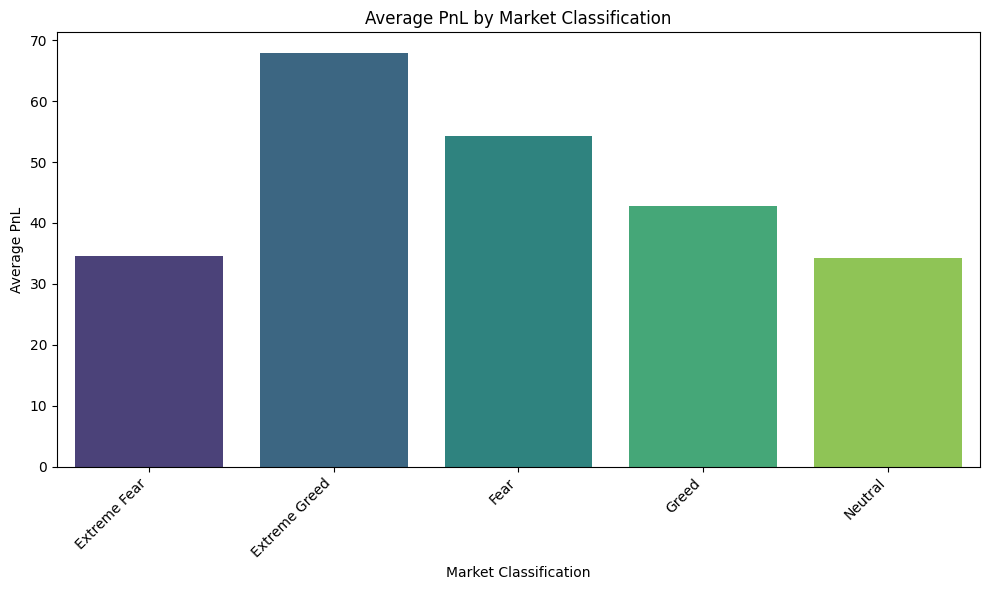

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_pnl_by_classification.index, y=avg_pnl_by_classification.values, palette='viridis')
plt.title('Average PnL by Market Classification')
plt.xlabel('Market Classification')
plt.ylabel('Average PnL')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a FutureWarning about the `palette` argument in `sns.barplot`. To address this and follow best practices, I will explicitly set the `hue` argument to the x-axis variable and `legend=False` when creating the bar chart for win rates.



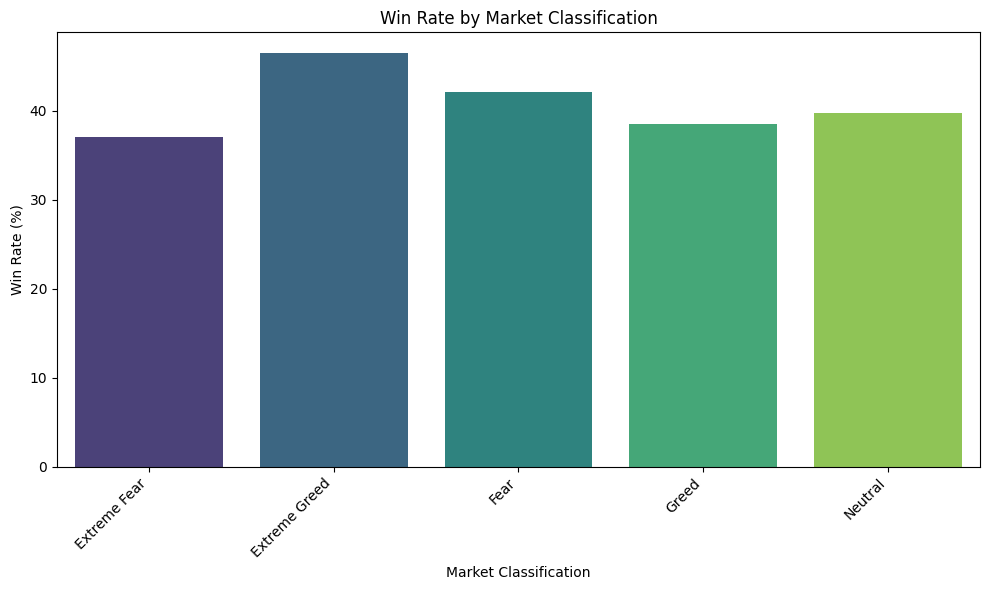

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x=win_rate_by_classification.index, y=win_rate_by_classification.values, hue=win_rate_by_classification.index, palette='viridis', legend=False)
plt.title('Win Rate by Market Classification')
plt.xlabel('Market Classification')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the average loss per trade for each market classification, I will create a bar chart using the `avg_loss_by_classification` data. This will provide a clear comparison of how losses vary across different sentiment periods.



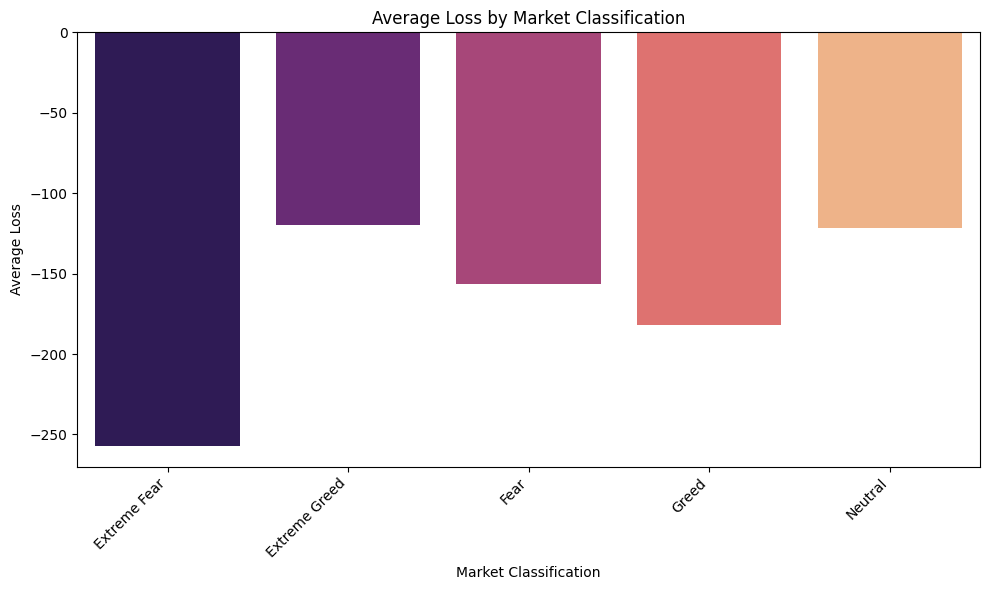

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_loss_by_classification.index, y=avg_loss_by_classification.values, hue=avg_loss_by_classification.index, palette='magma', legend=False)
plt.title('Average Loss by Market Classification')
plt.xlabel('Market Classification')
plt.ylabel('Average Loss')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyze Trader Behavior Changes on Fear vs Greed Days

### Subtask:
Calculate the total number of trades for each trader across different market classifications ('Fear', 'Greed', etc.) to understand how trading frequency varies with sentiment.


**Reasoning**:
To understand how trading frequency varies with sentiment, I will group the `merged_data` DataFrame by 'Account' and 'classification', then count the total number of trades for each group.



In [34]:
total_trades_per_trader_by_classification = merged_data.groupby(['Account', 'classification']).size().reset_index(name='Total Trades')

print("Total trades per trader by classification calculated successfully.")
total_trades_per_trader_by_classification.head()

Total trades per trader by classification calculated successfully.


,Account,classification,Total Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,100
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,945
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1778
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,574
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,421


## Analyze Trader Behavior Changes on Fear vs Greed Days

### Subtask:
Calculate the average trade size per trader for each classification.


**Reasoning**:
To determine the average trade size per trader for each classification, I will group the `merged_data` DataFrame by 'Account' and 'classification' and then calculate the mean of the 'Size USD' column. Afterwards, I will reset the index and rename the 'Size USD' column to 'Average Trade Size (USD)'.



In [35]:
average_trade_size_per_trader_by_classification = merged_data.groupby(['Account', 'classification'])['Size USD'].mean().reset_index()

average_trade_size_per_trader_by_classification.rename(columns={'Size USD': 'Average Trade Size (USD)'}, inplace=True)

print("Average trade size per trader by classification calculated successfully.")
average_trade_size_per_trader_by_classification.head()

Average trade size per trader by classification calculated successfully.


,Account,classification,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,15071.008600
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,12080.270550
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,17020.494876
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,15134.130383
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,23336.999311


## Analyze Trader Behavior Changes on Fear vs Greed Days

### Subtask:
Calculate the Long/Short ratio per trader for each classification.


**Reasoning**:
To calculate the Long/Short ratio per trader for each classification, I will group the `merged_data` DataFrame by 'Account', 'classification', and 'Side', and count the number of trades. This will be the first step in preparing the data for ratio calculation.



In [36]:
trade_counts_by_classification = merged_data.groupby(['Account', 'classification', 'Side']).size().reset_index(name='Trade Count')

print("Trade counts per 'Side' for each 'Account' and 'classification' calculated successfully.")
print(trade_counts_by_classification.head())

Trade counts per 'Side' for each 'Account' and 'classification' calculated successfully.
                                      Account classification  Side  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012   Extreme Fear   BUY   
1  0x083384f897ee0f19899168e3b1bec365f52a9012   Extreme Fear  SELL   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  Extreme Greed   BUY   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  Extreme Greed  SELL   
4  0x083384f897ee0f19899168e3b1bec365f52a9012           Fear   BUY   

   Trade Count  
0           37  
1           63  
2          246  
3          699  
4         1030  


**Reasoning**:
To continue calculating the Long/Short ratio, I will unstack the `trade_counts_by_classification` DataFrame to create separate 'BUY' and 'SELL' columns, filling any missing values with 0. This reshapes the data to facilitate the ratio calculation.



In [37]:
trade_counts_unstacked = trade_counts_by_classification.pivot_table(index=['Account', 'classification'], columns='Side', values='Trade Count', fill_value=0).reset_index()

print("Trade counts unstacked and ready for ratio calculation.")
print(trade_counts_unstacked.head())

Trade counts unstacked and ready for ratio calculation.
Side                                     Account classification     BUY   SELL
0     0x083384f897ee0f19899168e3b1bec365f52a9012   Extreme Fear    37.0   63.0
1     0x083384f897ee0f19899168e3b1bec365f52a9012  Extreme Greed   246.0  699.0
2     0x083384f897ee0f19899168e3b1bec365f52a9012           Fear  1030.0  748.0
3     0x083384f897ee0f19899168e3b1bec365f52a9012          Greed   153.0  421.0
4     0x083384f897ee0f19899168e3b1bec365f52a9012        Neutral   245.0  176.0


**Reasoning**:
Now that the trade counts are unstacked, I will calculate the 'Long/Short Ratio' by dividing the 'BUY' counts by the 'SELL' counts. I will handle potential division-by-zero errors by replacing infinite values with NaN and then filling NaN values with 0, as specified in the instructions. The index has already been reset in the previous step.



In [38]:
trade_counts_unstacked['Long/Short Ratio'] = trade_counts_unstacked['BUY'] / trade_counts_unstacked['SELL']
trade_counts_unstacked.replace([np.inf, -np.inf], np.nan, inplace=True)
trade_counts_unstacked['Long/Short Ratio'].fillna(0, inplace=True)

long_short_ratio_per_trader_by_classification = trade_counts_unstacked.copy()

print("Long/Short ratio per trader for each classification calculated successfully.")
print(long_short_ratio_per_trader_by_classification.head())

Long/Short ratio per trader for each classification calculated successfully.
Side                                     Account classification     BUY  \
0     0x083384f897ee0f19899168e3b1bec365f52a9012   Extreme Fear    37.0   
1     0x083384f897ee0f19899168e3b1bec365f52a9012  Extreme Greed   246.0   
2     0x083384f897ee0f19899168e3b1bec365f52a9012           Fear  1030.0   
3     0x083384f897ee0f19899168e3b1bec365f52a9012          Greed   153.0   
4     0x083384f897ee0f19899168e3b1bec365f52a9012        Neutral   245.0   

Side   SELL  Long/Short Ratio  
0      63.0          0.587302  
1     699.0          0.351931  
2     748.0          1.377005  
3     421.0          0.363420  
4     176.0          1.392045  


/tmp/ipython-input-24681/427132620.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  trade_counts_unstacked['Long/Short Ratio'].fillna(0, inplace=True)


**Reasoning**:
The previous code generated a `FutureWarning` regarding the use of `inplace=True` in chained assignments. To resolve this, I will modify the line that fills NaN values in the 'Long/Short Ratio' column to assign the result of `fillna()` directly back to the column, preventing the warning and ensuring consistent behavior in future pandas versions.



In [39]:
trade_counts_unstacked['Long/Short Ratio'] = trade_counts_unstacked['BUY'] / trade_counts_unstacked['SELL']
trade_counts_unstacked.replace([np.inf, -np.inf], np.nan, inplace=True)
trade_counts_unstacked['Long/Short Ratio'] = trade_counts_unstacked['Long/Short Ratio'].fillna(0)

long_short_ratio_per_trader_by_classification = trade_counts_unstacked.copy()

print("Long/Short ratio per trader for each classification calculated successfully.")
print(long_short_ratio_per_trader_by_classification.head())

Long/Short ratio per trader for each classification calculated successfully.
Side                                     Account classification     BUY  \
0     0x083384f897ee0f19899168e3b1bec365f52a9012   Extreme Fear    37.0   
1     0x083384f897ee0f19899168e3b1bec365f52a9012  Extreme Greed   246.0   
2     0x083384f897ee0f19899168e3b1bec365f52a9012           Fear  1030.0   
3     0x083384f897ee0f19899168e3b1bec365f52a9012          Greed   153.0   
4     0x083384f897ee0f19899168e3b1bec365f52a9012        Neutral   245.0   

Side   SELL  Long/Short Ratio  
0      63.0          0.587302  
1     699.0          0.351931  
2     748.0          1.377005  
3     421.0          0.363420  
4     176.0          1.392045  


## Segment Traders and Compare Performance

Segment traders into 'High Leverage vs Low Leverage Traders' (based on average trade size) and 'Frequent vs Rare Traders' (based on daily trade count). After segmentation, compare the performance (e.g., PnL, win rate) and behavior (e.g., trade frequency, Long/Short ratio) of these distinct groups during 'Fear' and 'Greed' days.


In [40]:
overall_avg_trade_size = average_trade_size_per_trader['Average Trade Size (USD)'].mean()
print(f"Overall Average Trade Size: {overall_avg_trade_size:.2f} USD")

Overall Average Trade Size: 6007.93 USD


In [41]:
average_trade_size_per_trader['Leverage Group'] = average_trade_size_per_trader['Average Trade Size (USD)'].apply(lambda x: 'High Leverage' if x > overall_avg_trade_size else 'Low Leverage')

print("Traders segmented into 'High Leverage' and 'Low Leverage' groups.")
print(average_trade_size_per_trader.head())

Traders segmented into 'High Leverage' and 'Low Leverage' groups.
                                      Account  Average Trade Size (USD)  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012              16159.576734   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd               1653.226327   
2  0x271b280974205ca63b716753467d5a371de622ab               8893.000898   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4                507.626933   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd               3138.894782   

  Leverage Group  
0  High Leverage  
1   Low Leverage  
2  High Leverage  
3   Low Leverage  
4   Low Leverage  


In [42]:
overall_avg_daily_trade_count = daily_trades_per_trader['Daily Trade Count'].mean()
print(f"Overall Average Daily Trade Count: {overall_avg_daily_trade_count:.2f}")

Overall Average Daily Trade Count: 90.23


In [43]:
daily_trades_per_trader['Trading Frequency Group'] = daily_trades_per_trader['Daily Trade Count'].apply(lambda x: 'Frequent' if x > overall_avg_daily_trade_count else 'Rare')

print("Traders segmented into 'Frequent' and 'Rare' groups based on daily trade count.")
print(daily_trades_per_trader.head())

Traders segmented into 'Frequent' and 'Rare' groups based on daily trade count.
                                      Account Timestamp IST  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-11   
1  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-17   
2  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-18   
3  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-22   
4  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-26   

   Daily Trade Count Trading Frequency Group  
0                177                Frequent  
1                 68                    Rare  
2                 40                    Rare  
3                 12                    Rare  
4                 27                    Rare  


In [44]:
merged_data = pd.merge(merged_data, average_trade_size_per_trader[['Account', 'Leverage Group']], on='Account', how='left')

print("Leverage group information merged into historical data.")
print(merged_data.head())

Leverage group information merged into historical data.
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY    2024-12-02        0.000000       Buy   
1        16.00    127.68  BUY    2024-12-02      986.524596       Buy   
2       144.09   1150.63  BUY    2024-12-02     1002.518996       Buy   
3       142.98   1142.04  BUY    2024-12-02     1146.558564       Buy   
4         8.73     69.75  BUY    2024-12-02     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Ord

In [45]:
merged_data = pd.merge(merged_data, daily_trades_per_trader[['Account', 'Timestamp IST', 'Trading Frequency Group']], on=['Account', 'Timestamp IST'], how='left')

print("Trading frequency group information merged into historical data.")
print(merged_data.head())

Trading frequency group information merged into historical data.
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY    2024-12-02        0.000000       Buy   
1        16.00    127.68  BUY    2024-12-02      986.524596       Buy   
2       144.09   1150.63  BUY    2024-12-02     1002.518996       Buy   
3       142.98   1142.04  BUY    2024-12-02     1146.558564       Buy   
4         8.73     69.75  BUY    2024-12-02     1289.488521       Buy   

   Closed PnL                                   Transaction Has

In [46]:
print("merged_data['Timestamp IST'] dtype:", merged_data['Timestamp IST'].dtype)
print("daily_trades_per_trader['Timestamp IST'] dtype:", daily_trades_per_trader['Timestamp IST'].dtype)

merged_data['Timestamp IST'] dtype: object
daily_trades_per_trader['Timestamp IST'] dtype: object


In [47]:
daily_trades_per_trader['Timestamp IST'] = pd.to_datetime(daily_trades_per_trader['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

print("daily_trades_per_trader 'Timestamp IST' column converted to date objects.")
print(daily_trades_per_trader.head())

daily_trades_per_trader 'Timestamp IST' column converted to date objects.
                                      Account Timestamp IST  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-11   
1  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-17   
2  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-18   
3  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-22   
4  0x083384f897ee0f19899168e3b1bec365f52a9012    2024-11-26   

   Daily Trade Count Trading Frequency Group  
0                177                Frequent  
1                 68                    Rare  
2                 40                    Rare  
3                 12                    Rare  
4                 27                    Rare  


In [48]:
merged_data = pd.merge(merged_data, daily_trades_per_trader[['Account', 'Timestamp IST', 'Trading Frequency Group']], on=['Account', 'Timestamp IST'], how='left')

print("Trading frequency group information merged into historical data successfully.")
print(merged_data.head())

Trading frequency group information merged into historical data successfully.
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY    2024-12-02        0.000000       Buy   
1        16.00    127.68  BUY    2024-12-02      986.524596       Buy   
2       144.09   1150.63  BUY    2024-12-02     1002.518996       Buy   
3       142.98   1142.04  BUY    2024-12-02     1146.558564       Buy   
4         8.73     69.75  BUY    2024-12-02     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee

In [49]:
if 'Trading Frequency Group_x' in merged_data.columns and 'Trading Frequency Group_y' in merged_data.columns:
    merged_data.drop(columns=['Trading Frequency Group_x'], inplace=True)
    merged_data.rename(columns={'Trading Frequency Group_y': 'Trading Frequency Group'}, inplace=True)

print("Corrected 'Trading Frequency Group' column in merged_data.")
print(merged_data.head())

Corrected 'Trading Frequency Group' column in merged_data.
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY    2024-12-02        0.000000       Buy   
1        16.00    127.68  BUY    2024-12-02      986.524596       Buy   
2       144.09   1150.63  BUY    2024-12-02     1002.518996       Buy   
3       142.98   1142.04  BUY    2024-12-02     1146.558564       Buy   
4         8.73     69.75  BUY    2024-12-02     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     

**Reasoning**:
To analyze how 'High Leverage' and 'Low Leverage' traders perform across different market classifications, I will group the `merged_data` DataFrame by 'Leverage Group' and 'classification' and then calculate the mean of 'Closed PnL'. This will provide insight into the average profitability of each leverage group during different market sentiments.



In [50]:
avg_pnl_by_leverage_and_classification = merged_data.groupby(['Leverage Group', 'classification'])['Closed PnL'].mean().unstack()

print("Average PnL by Leverage Group and Market Classification:")
print(avg_pnl_by_leverage_and_classification)

Average PnL by Leverage Group and Market Classification:
classification  Extreme Fear  Extreme Greed        Fear       Greed    Neutral
Leverage Group                                                                
High Leverage      67.141944      27.414043  118.717229  117.391243  72.635692
Low Leverage       24.233921      72.742884   29.608507   26.484294  24.346443


In [51]:
total_trades_by_leverage_and_classification = merged_data.groupby(['Leverage Group', 'classification']).size().unstack()

print("Total Trades by Leverage Group and Market Classification:")
print(total_trades_by_leverage_and_classification)

Total Trades by Leverage Group and Market Classification:
classification  Extreme Fear  Extreme Greed   Fear  Greed  Neutral
Leverage Group                                                    
High Leverage           5139           4279  17128   8997     7774
Low Leverage           16261          35713  44709  41306    29912


In [52]:
profitable_trades_by_leverage_and_classification = merged_data[merged_data['Closed PnL'] > 0].groupby(['Leverage Group', 'classification']).size().unstack()

print("Profitable Trades by Leverage Group and Market Classification:")
print(profitable_trades_by_leverage_and_classification)

Profitable Trades by Leverage Group and Market Classification:
classification  Extreme Fear  Extreme Greed   Fear  Greed  Neutral
Leverage Group                                                    
High Leverage           1855            972   7161   3313     3322
Low Leverage            6076          17622  18858  16045    11639


In [53]:
win_rate_by_leverage_and_classification = (profitable_trades_by_leverage_and_classification / total_trades_by_leverage_and_classification) * 100

print("Win Rate by Leverage Group and Market Classification:")
print(win_rate_by_leverage_and_classification)

Win Rate by Leverage Group and Market Classification:
classification  Extreme Fear  Extreme Greed       Fear      Greed    Neutral
Leverage Group                                                              
High Leverage      36.096517      22.715588  41.808734  36.823386  42.732184
Low Leverage       37.365476      49.343376  42.179427  38.844236  38.910805


In [54]:
avg_loss_by_leverage_and_classification = merged_data[merged_data['Closed PnL'] < 0].groupby(['Leverage Group', 'classification'])['Closed PnL'].mean().unstack()

print("Average Loss by Leverage Group and Market Classification:")
print(avg_loss_by_leverage_and_classification)

Average Loss by Leverage Group and Market Classification:
classification  Extreme Fear  Extreme Greed        Fear       Greed  \
Leverage Group                                                        
High Leverage    -539.231162    -559.066963 -418.566154 -685.688552   
Low Leverage     -193.892119     -45.060571  -59.797781 -130.641189   

classification     Neutral  
Leverage Group              
High Leverage  -461.147779  
Low Leverage    -53.384842  


<Figure size 1200x700 with 0 Axes>

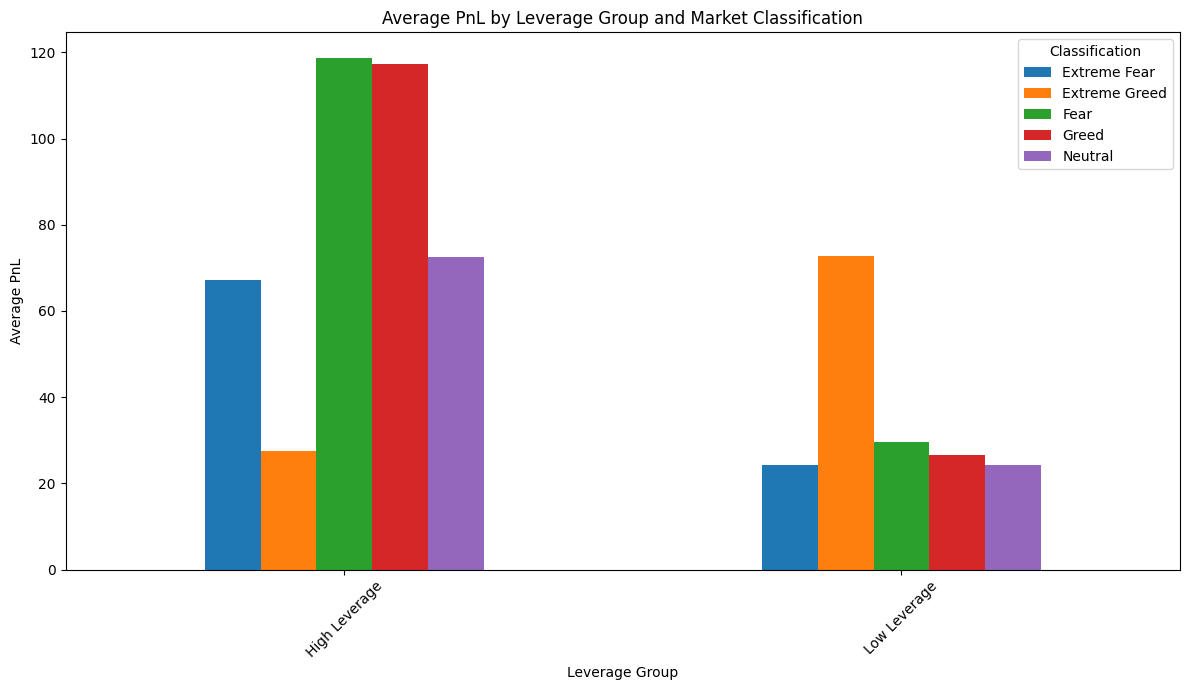

In [55]:
plt.figure(figsize=(12, 7))
avg_pnl_by_leverage_and_classification.plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('Average PnL by Leverage Group and Market Classification')
plt.xlabel('Leverage Group')
plt.ylabel('Average PnL')
plt.legend(title='Classification')
plt.tight_layout()
plt.show()

## Segment Traders and Compare Performance

Visualize the win rate for High and Low Leverage traders across different market classifications.


<Figure size 1200x700 with 0 Axes>

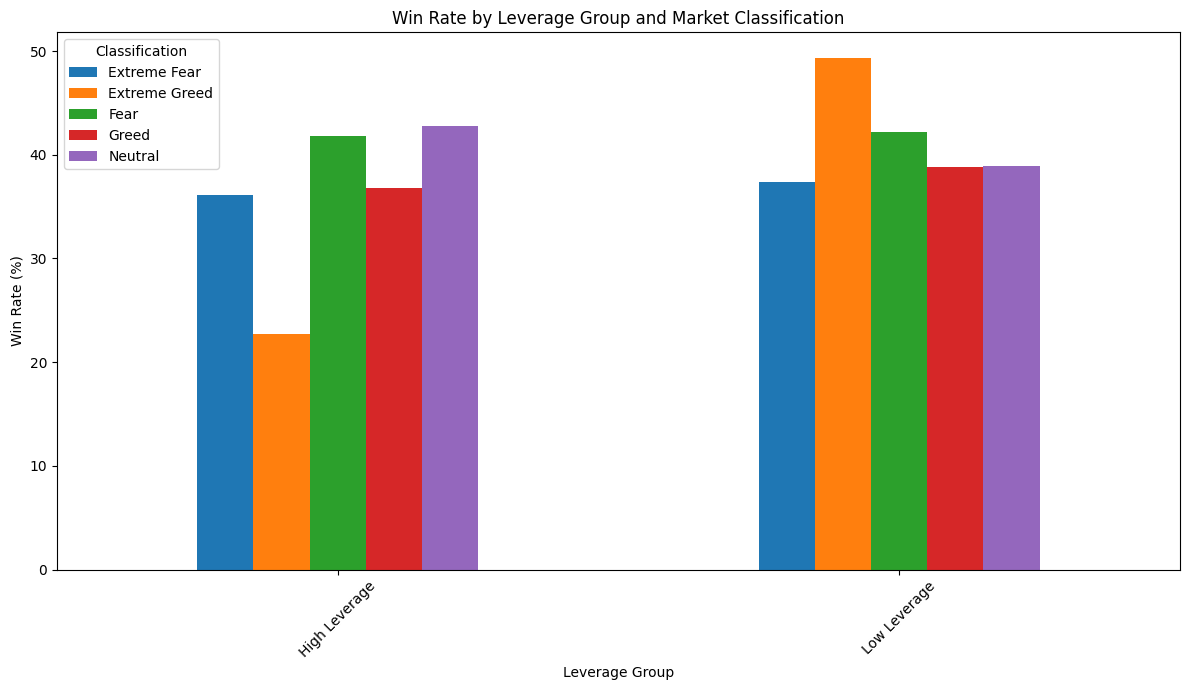

In [56]:
plt.figure(figsize=(12, 7))
win_rate_by_leverage_and_classification.plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('Win Rate by Leverage Group and Market Classification')
plt.xlabel('Leverage Group')
plt.ylabel('Win Rate (%)')
plt.legend(title='Classification')
plt.tight_layout()
plt.show()

## Segment Traders and Compare Performance

Visualize the average loss for High and Low Leverage traders across different market classifications.


<Figure size 1200x700 with 0 Axes>

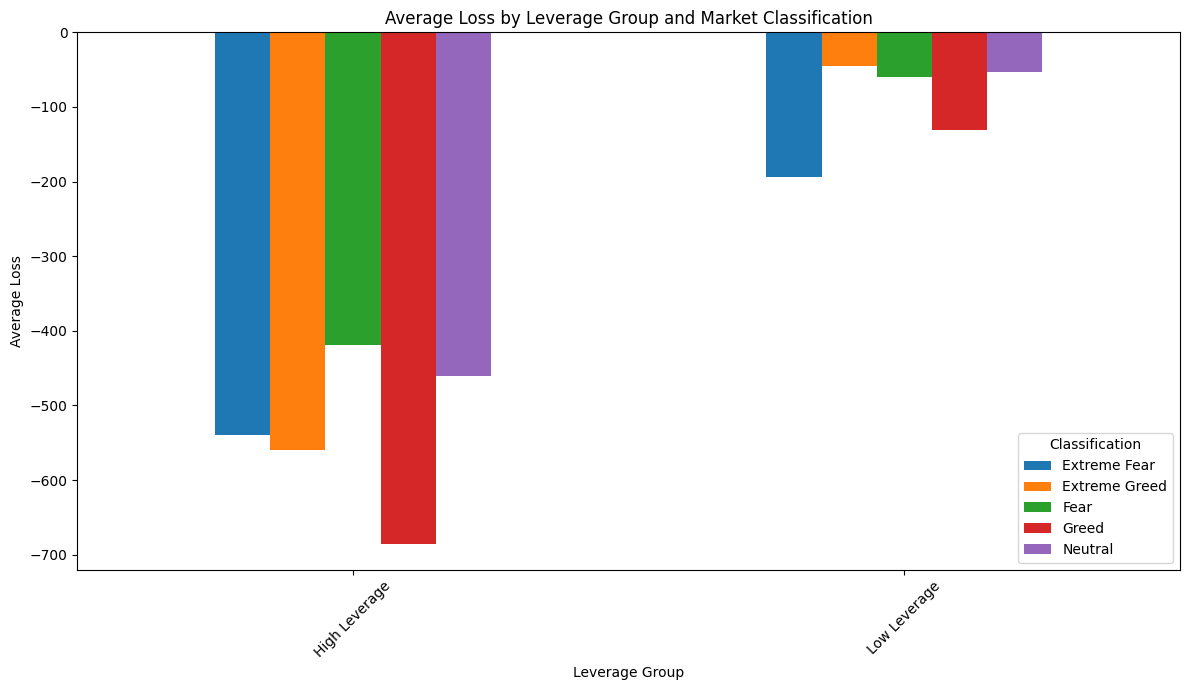

In [57]:
plt.figure(figsize=(12, 7))
avg_loss_by_leverage_and_classification.plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('Average Loss by Leverage Group and Market Classification')
plt.xlabel('Leverage Group')
plt.ylabel('Average Loss')
plt.legend(title='Classification')
plt.tight_layout()
plt.show()

## Segment Traders and Compare Performance

Calculate the average PnL for 'Frequent' and 'Rare' traders across different market classifications.


In [58]:
avg_pnl_by_frequency_and_classification = merged_data.groupby(['Trading Frequency Group', 'classification'])['Closed PnL'].mean().unstack()

print("Average PnL by Trading Frequency Group and Market Classification:")
print(avg_pnl_by_frequency_and_classification)

Average PnL by Trading Frequency Group and Market Classification:
classification           Extreme Fear  Extreme Greed       Fear      Greed  \
Trading Frequency Group                                                      
Frequent                    30.965564      51.480048  46.828320  37.844551   
Rare                        49.493724     112.419721  83.584145  56.058508   

classification             Neutral  
Trading Frequency Group             
Frequent                 23.375346  
Rare                     78.870685  


In [59]:
total_trades_by_frequency_and_classification = merged_data.groupby(['Trading Frequency Group', 'classification']).size().unstack()

print("Total Trades by Trading Frequency Group and Market Classification:")
print(total_trades_by_frequency_and_classification)

Total Trades by Trading Frequency Group and Market Classification:
classification           Extreme Fear  Extreme Greed   Fear  Greed  Neutral
Trading Frequency Group                                                    
Frequent                        17274          29221  49283  36773    30262
Rare                             4126          10771  12554  13530     7424


In [60]:
profitable_trades_by_frequency_and_classification = merged_data[merged_data['Closed PnL'] > 0].groupby(['Trading Frequency Group', 'classification']).size().unstack()

print("Profitable Trades by Trading Frequency Group and Market Classification:")
print(profitable_trades_by_frequency_and_classification)

Profitable Trades by Trading Frequency Group and Market Classification:
classification           Extreme Fear  Extreme Greed   Fear  Greed  Neutral
Trading Frequency Group                                                    
Frequent                         6640          14298  21198  14083    12024
Rare                             1291           4296   4821   5275     2937


In [61]:
win_rate_by_frequency_and_classification = (profitable_trades_by_frequency_and_classification / total_trades_by_frequency_and_classification) * 100

print("Win Rate by Trading Frequency Group and Market Classification:")
print(win_rate_by_frequency_and_classification)

Win Rate by Trading Frequency Group and Market Classification:
classification           Extreme Fear  Extreme Greed       Fear      Greed  \
Trading Frequency Group                                                      
Frequent                    38.439273      48.930564  43.012804  38.297120   
Rare                        31.289384      39.884876  38.402103  38.987435   

classification             Neutral  
Trading Frequency Group             
Frequent                 39.732998  
Rare                     39.560884  


In [62]:
avg_loss_by_frequency_and_classification = merged_data[merged_data['Closed PnL'] < 0].groupby(['Trading Frequency Group', 'classification'])['Closed PnL'].mean().unstack()

print("Average Loss by Trading Frequency Group and Market Classification:")
print(avg_loss_by_frequency_and_classification)

Average Loss by Trading Frequency Group and Market Classification:
classification           Extreme Fear  Extreme Greed        Fear       Greed  \
Trading Frequency Group                                                        
Frequent                  -194.607815     -24.362649  -99.143519 -155.243819   
Rare                      -594.264764    -355.443490 -395.256348 -362.823768   

classification              Neutral  
Trading Frequency Group              
Frequent                -116.481976  
Rare                    -157.701386  


<Figure size 1200x700 with 0 Axes>

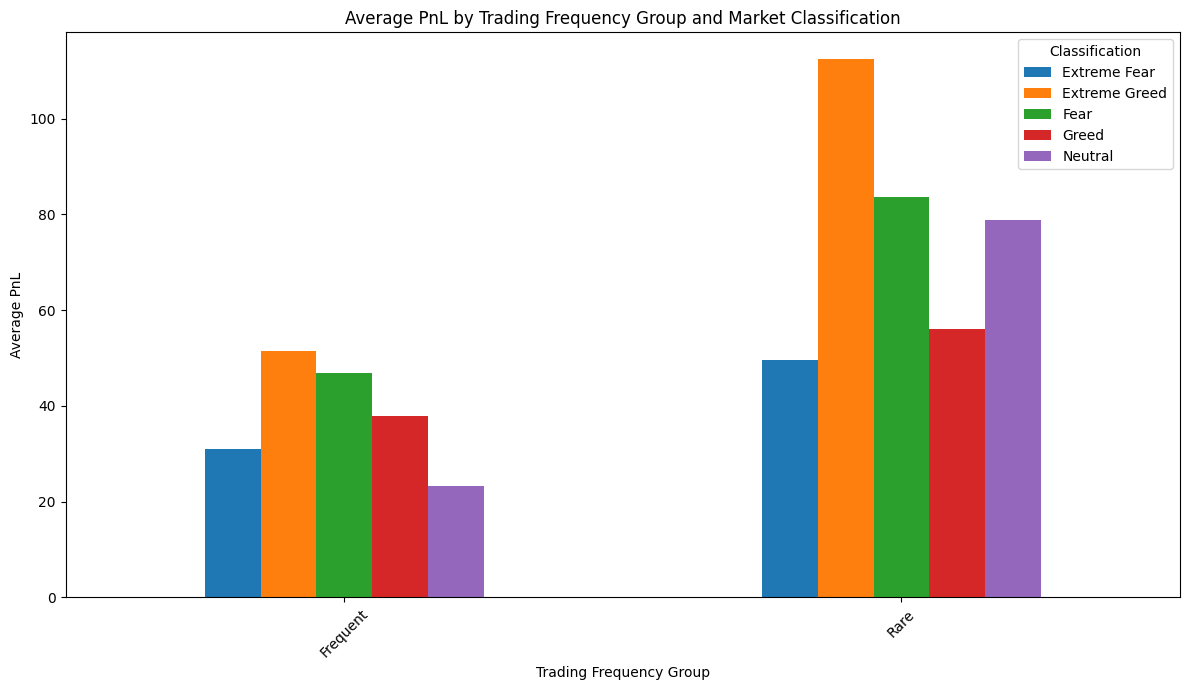

In [63]:
plt.figure(figsize=(12, 7))
avg_pnl_by_frequency_and_classification.plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('Average PnL by Trading Frequency Group and Market Classification')
plt.xlabel('Trading Frequency Group')
plt.ylabel('Average PnL')
plt.legend(title='Classification')
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

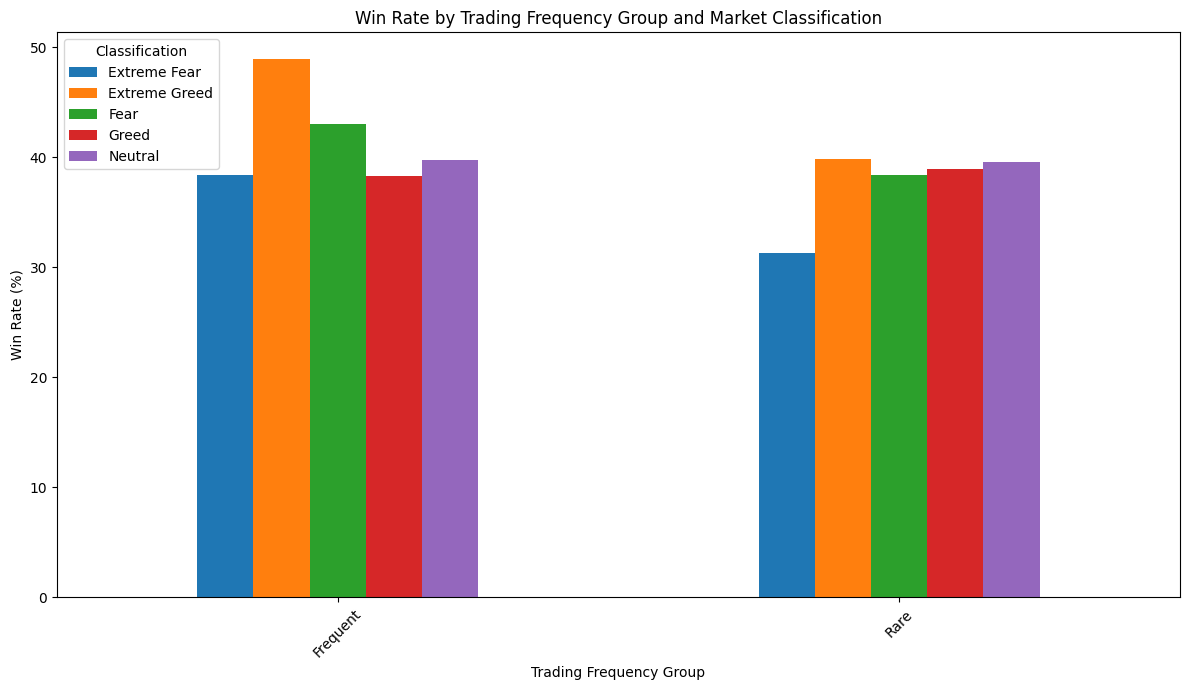

In [64]:
plt.figure(figsize=(12, 7))
win_rate_by_frequency_and_classification.plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('Win Rate by Trading Frequency Group and Market Classification')
plt.xlabel('Trading Frequency Group')
plt.ylabel('Win Rate (%)')
plt.legend(title='Classification')
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

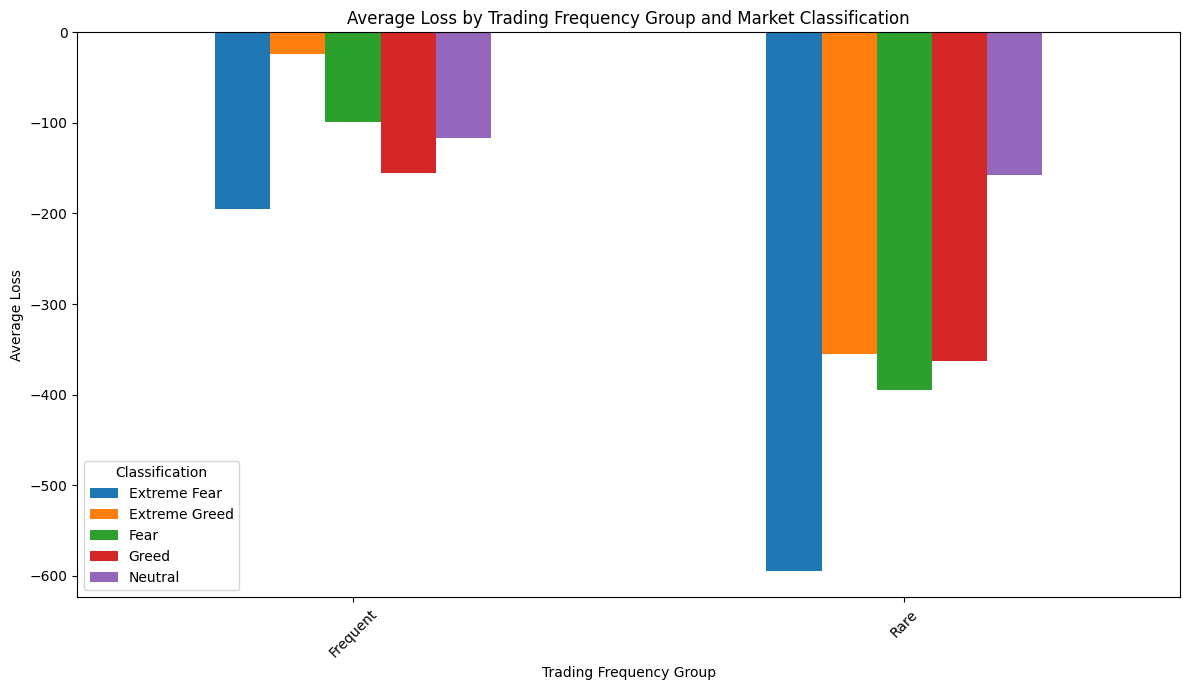

In [65]:
plt.figure(figsize=(12, 7))
avg_loss_by_frequency_and_classification.plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('Average Loss by Trading Frequency Group and Market Classification')
plt.xlabel('Trading Frequency Group')
plt.ylabel('Average Loss')
plt.legend(title='Classification')
plt.tight_layout()
plt.show()